# NYSE TAQ Sample Inventory and Coverage

This notebook summarizes what is available on the NYSE sample page, what has already been downloaded locally, and what analysis has already been done.

Main purpose: help decide whether we need more downloads before emailing Professor Schafer or continuing the project.

## Plain-English summary

- The NYSE sample page has many different TAQ sample feeds.
- We have downloaded the core files needed for a first-pass feature engineering study: symbol lookup, quote updates, NYSE trades, and full-day consolidated trades.
- We have **not** downloaded everything on the page. Downloading everything would be much larger, roughly hundreds of GB.
- The files we already have are enough to explain the data structure, build initial features, and propose a nonlinear dimension reduction direction.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

RESEARCH_DIR = Path('.')
DATA_DIR = Path('../data/nyse_taq_samples')
inventory_path = RESEARCH_DIR / 'nyse_taq_sample_inventory.csv'

## 1. Load inventory of the NYSE sample page

The inventory file was created by scanning the top-level NYSE sample directories and their file listings. It is metadata only; it does not download all the raw data.

In [2]:
inv = pd.read_csv(inventory_path)
inv['size_bytes'] = pd.to_numeric(inv['size_text'], errors='coerce')
inv['size_gb'] = inv['size_bytes'] / 1e9
files = inv[inv['type'].eq('file')].copy()

summary = pd.DataFrame({
    'metric': [
        'top-level directories scanned',
        'file entries found',
        'files already downloaded',
        'files not downloaded',
        'total known sample size (GB)',
        'downloaded known size (GB)',
        'not downloaded known size (GB)',
    ],
    'value': [
        inv['category'].nunique(),
        len(files),
        int(files['downloaded'].sum()),
        int((~files['downloaded']).sum()),
        round(files['size_gb'].sum(), 2),
        round(files.loc[files['downloaded'], 'size_gb'].sum(), 2),
        round(files.loc[~files['downloaded'], 'size_gb'].sum(), 2),
    ]
})
summary

,metric,value
0,top-level directories scanned,30.00
1,file entries found,726.00
2,files already downloaded,4.00
3,files not downloaded,722.00
4,total known sample size (GB),211.90
5,downloaded known size (GB),4.99
6,not downloaded known size (GB),206.91


## 2. What has already been downloaded

These are the raw NYSE sample files already present locally.

In [3]:
downloaded = files[files['downloaded']].copy()
downloaded[['category', 'name', 'size_gb', 'local_file']].sort_values('size_gb', ascending=False)

,category,name,size_gb,local_file
13,DAILY TAQ,EQY_US_ALL_TRADE_20260102.gz,3.234098,data/nyse_taq_samples/EQY_US_ALL_TRADE_2026010...
469,TAQ NYSE BBO,EQY_US_TAQ_NYSE_BBO_1_20231002.gz,1.657498,data/nyse_taq_samples/EQY_US_TAQ_NYSE_BBO_1_20...
657,TAQ NYSE TRADES,EQY_US_TAQ_NYSE_TRADES_20231002.gz,0.100126,data/nyse_taq_samples/EQY_US_TAQ_NYSE_TRADES_2...
11,DAILY TAQ,EQY_US_ALL_REF_MASTER_20260102.gz,0.000410,data/nyse_taq_samples/EQY_US_ALL_REF_MASTER_20...


### Plain-English meaning of downloaded files

| Downloaded file | What it means | Why it was useful |
|---|---|---|
| Reference master | Symbol lookup file | Tells us what each ticker is |
| Consolidated full-day trades | Trades across venues for a whole day | Gives volume, VWAP, trade count, and intraday profiles |
| NYSE BBO quote file | NYSE best bid/ask updates | Gives spreads, mid-price, quote intensity, and displayed depth |
| NYSE venue trades | Trades on NYSE only | Useful for venue-specific trade-flow features |

## 3. What is available but not yet downloaded

There are many other sample feeds on the page. The plot below shows how many files each directory contains and how much data each directory represents.

In [4]:
cat = files.groupby('category').agg(
    file_count=('name', 'count'),
    downloaded_files=('downloaded', 'sum'),
    size_gb=('size_gb', 'sum'),
).reset_index()
cat['missing_files'] = cat['file_count'] - cat['downloaded_files']
cat = cat.sort_values('size_gb', ascending=False)
cat.head(15)

,category,file_count,downloaded_files,size_gb,missing_files
0,DAILY TAQ,70,2,97.430166,68
13,TAQ NYSE ARCA INTEGRATED FEED,39,0,29.845461,39
5,TAQ GROUP SHORT SALES & SHORT VOLUME,99,0,21.862621,99
16,TAQ NYSE BBO,65,1,13.634110,64
22,TAQ NYSE OPENBOOK,18,0,13.076235,18
18,TAQ NYSE INTEGRATED FEED,30,0,11.787853,30
4,TAQ GOTC BBO FEED,33,0,4.503268,33
25,TAQ NYSE TEXAS INTEGRATED FEED,28,0,3.407142,28
19,TAQ NYSE NATIONAL BBO,28,0,2.318543,28
20,TAQ NYSE NATIONAL INTEGRATED FEED,14,0,2.137288,14


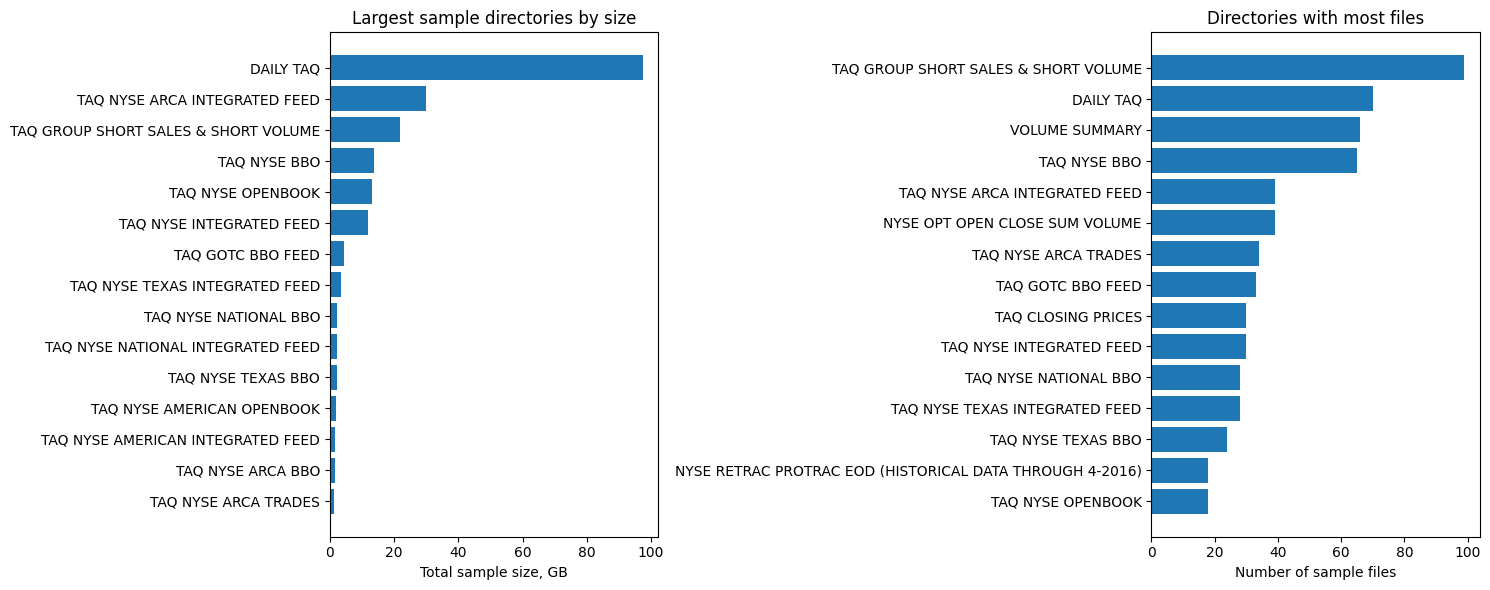

In [5]:
top = cat.head(15).sort_values('size_gb')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top['category'], top['size_gb'])
axes[0].set_title('Largest sample directories by size')
axes[0].set_xlabel('Total sample size, GB')

top_count = cat.sort_values('file_count', ascending=False).head(15).sort_values('file_count')
axes[1].barh(top_count['category'], top_count['file_count'])
axes[1].set_title('Directories with most files')
axes[1].set_xlabel('Number of sample files')

plt.tight_layout()

## 4. Download coverage

This shows how much of the sample page is already local. We intentionally started with representative files rather than downloading everything.

In [6]:
coverage = pd.DataFrame({
    'status': ['downloaded', 'not downloaded'],
    'files': [files['downloaded'].sum(), (~files['downloaded']).sum()],
    'size_gb': [files.loc[files['downloaded'], 'size_gb'].sum(), files.loc[~files['downloaded'], 'size_gb'].sum()]
})
coverage

,status,files,size_gb
0,downloaded,4,4.992133
1,not downloaded,722,206.907670


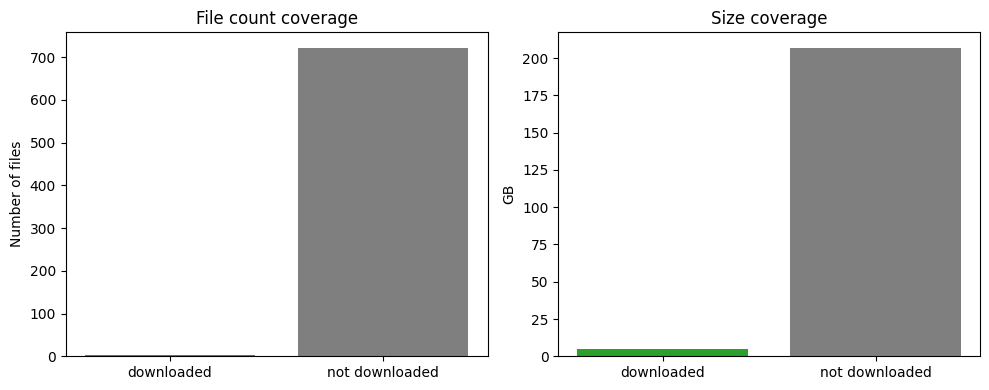

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(coverage['status'], coverage['files'], color=['tab:green', 'tab:gray'])
axes[0].set_title('File count coverage')
axes[0].set_ylabel('Number of files')

axes[1].bar(coverage['status'], coverage['size_gb'], color=['tab:green', 'tab:gray'])
axes[1].set_title('Size coverage')
axes[1].set_ylabel('GB')

plt.tight_layout()

## 5. Largest files not yet downloaded

If we download more, these are the files that drive storage usage. The full page is not small.

In [8]:
largest_missing = files[~files['downloaded']].sort_values('size_gb', ascending=False).head(20)
largest_missing[['category', 'name', 'size_gb', 'url']]

,category,name,size_gb,url
9,DAILY TAQ,EQY_US_ALL_NBBO_20260102.gz,9.566494,https://ftp.nyse.com/Historical%20Data%20Sampl...
10,DAILY TAQ,EQY_US_ALL_NBBO_20260105.gz,8.422365,https://ftp.nyse.com/Historical%20Data%20Sampl...
53,DAILY TAQ,SPLITS_US_ALL_BBO_S_20260102.gz,5.715544,https://ftp.nyse.com/Historical%20Data%20Sampl...
54,DAILY TAQ,SPLITS_US_ALL_BBO_S_20260105.gz,4.370819,https://ftp.nyse.com/Historical%20Data%20Sampl...
334,TAQ NYSE ARCA INTEGRATED FEED,EQY_US_ALL_ARCA_BOOK_20110308.csv.gz,3.871729,https://ftp.nyse.com/Historical%20Data%20Sampl...
14,DAILY TAQ,EQY_US_ALL_TRADE_20260105.gz,3.783085,https://ftp.nyse.com/Historical%20Data%20Sampl...
33,DAILY TAQ,SPLITS_US_ALL_BBO_I_20260102.gz,3.453502,https://ftp.nyse.com/Historical%20Data%20Sampl...
333,TAQ NYSE ARCA INTEGRATED FEED,EQY_US_ALL_ARCA_BOOK_20091123.csv.gz,3.171527,https://ftp.nyse.com/Historical%20Data%20Sampl...
34,DAILY TAQ,SPLITS_US_ALL_BBO_I_20260105.gz,2.937183,https://ftp.nyse.com/Historical%20Data%20Sampl...
55,DAILY TAQ,SPLITS_US_ALL_BBO_T_20260102.gz,2.568508,https://ftp.nyse.com/Historical%20Data%20Sampl...


## 6. What analysis has already been done

Using the downloaded files, I already produced:

- parsers for BBO quote data and trade data,
- one-minute BBO features: spread, quote intensity, mid-price return, displayed depth imbalance,
- one-minute consolidated trade bars: volume, trade count, VWAP, average trade size, intraday volume and volatility profiles,
- simple predictive experiments, mainly to test whether the features behave sensibly,
- a proposed nonlinear dimension reduction setup using intraday curves.

## 7. Visualizing the processed trade features

The consolidated trade bars file is the most interpretable processed output. Each row is one symbol-minute.

In [9]:
trade_bars_path = RESEARCH_DIR / 'taq_consolidated_trade_bars.csv'
trade_bars = pd.read_csv(trade_bars_path)
trade_bars.head()

,time_bin,total_volume,trade_count,avg_price,vwap,open_price,high_price,low_price,close_price,avg_volume,max_volume,symbol,minute_return,minute_range,realized_var,dollar_volume,time_of_day
0,240,1788,75,273.070667,273.176326,272.17,273.30,272.17,273.08,23.840000,165,AAPL,0.003338,41.518169,1.114172e-05,488439.27,04:00
1,241,791,39,273.448974,273.410164,273.29,273.90,273.24,273.50,20.282051,100,AAPL,0.000768,24.150170,5.900075e-07,216267.44,04:01
2,242,12,6,273.295000,273.302500,273.25,273.32,273.25,273.32,2.000000,4,AAPL,0.000256,2.561757,6.560916e-08,3279.63,04:02
3,243,66,8,273.315000,273.319091,273.32,273.32,273.30,273.30,8.250000,22,AAPL,-0.000073,0.731743,5.354870e-09,18039.06,04:03
4,244,74,10,273.358000,273.371622,273.34,273.42,273.32,273.40,7.400000,30,AAPL,0.000219,3.658447,4.817268e-08,20229.50,04:04


In [10]:
trade_summary = trade_bars.groupby('symbol').agg(
    total_volume=('total_volume', 'sum'),
    total_trades=('trade_count', 'sum'),
    avg_trade_size=('avg_volume', 'mean'),
    vwap=('vwap', lambda x: np.average(x, weights=trade_bars.loc[x.index, 'total_volume'])),
    open_price=('open_price', 'first'),
    close_price=('close_price', 'last'),
    realized_var=('realized_var', 'sum'),
).reset_index()
trade_summary['daily_return_pct'] = 100 * np.log(trade_summary['close_price'] / trade_summary['open_price'])
trade_summary.sort_values('total_trades', ascending=False)

,symbol,total_volume,total_trades,avg_trade_size,vwap,open_price,close_price,realized_var,daily_return_pct
5,TSLA,89922555,1865256,56.745168,443.864800,458.63,441.4900,0.000624,-3.808842
4,SPY,93459938,1251790,652.864504,682.980148,685.32,683.1700,0.000086,-0.314215
3,QQQ,62536678,1088614,76.462157,614.899592,617.38,613.6900,0.000146,-0.599480
2,MSFT,29352772,716532,41.511162,474.412569,487.00,473.3000,0.009800,-2.853469
0,AAPL,48835599,642197,103.375618,271.727426,272.17,270.9607,0.000227,-0.445308
1,IWM,42081335,351337,870.008111,247.682018,247.70,248.7800,0.000242,0.435064


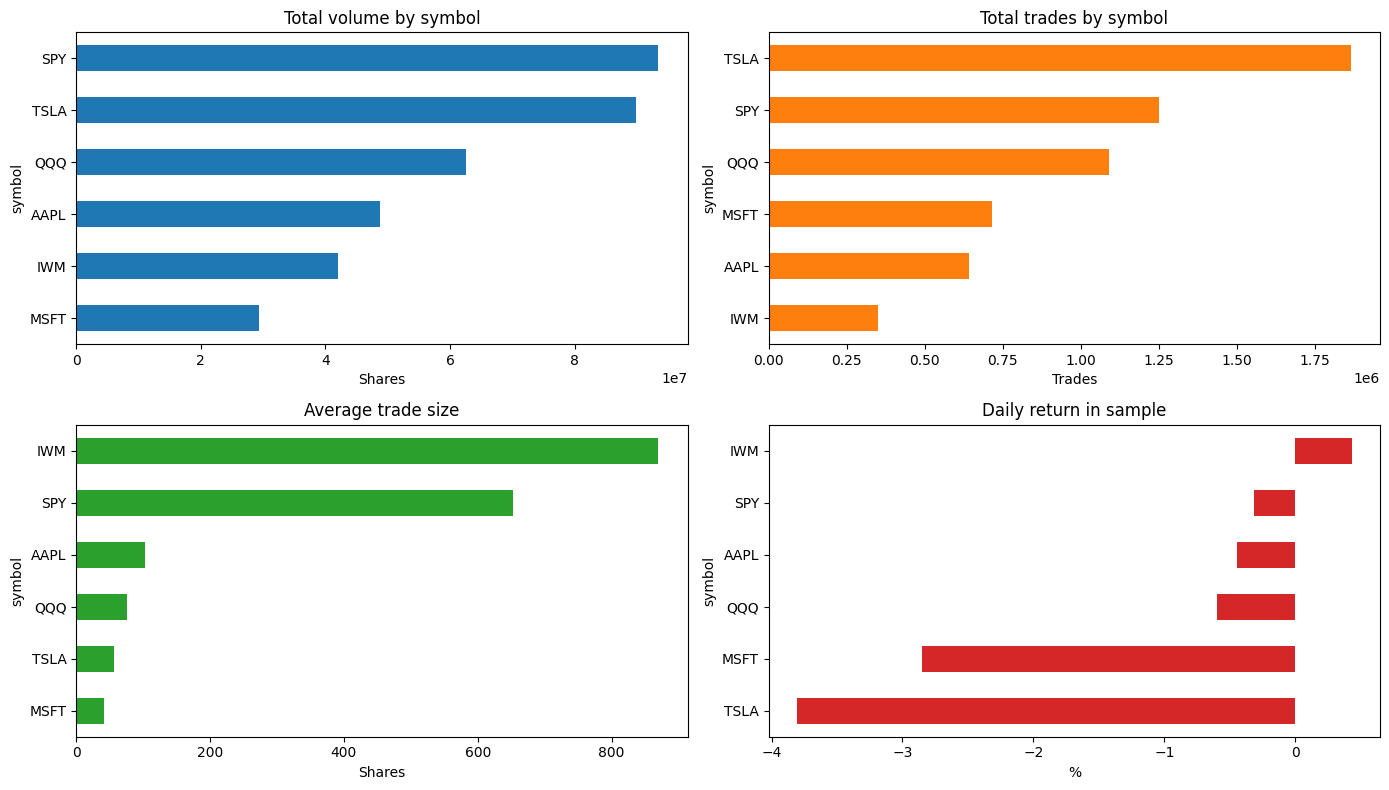

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

trade_summary.sort_values('total_volume').plot.barh(x='symbol', y='total_volume', ax=axes[0,0], legend=False)
axes[0,0].set_title('Total volume by symbol')
axes[0,0].set_xlabel('Shares')

trade_summary.sort_values('total_trades').plot.barh(x='symbol', y='total_trades', ax=axes[0,1], legend=False, color='tab:orange')
axes[0,1].set_title('Total trades by symbol')
axes[0,1].set_xlabel('Trades')

trade_summary.sort_values('avg_trade_size').plot.barh(x='symbol', y='avg_trade_size', ax=axes[1,0], legend=False, color='tab:green')
axes[1,0].set_title('Average trade size')
axes[1,0].set_xlabel('Shares')

trade_summary.sort_values('daily_return_pct').plot.barh(x='symbol', y='daily_return_pct', ax=axes[1,1], legend=False, color='tab:red')
axes[1,1].set_title('Daily return in sample')
axes[1,1].set_xlabel('%')

plt.tight_layout()

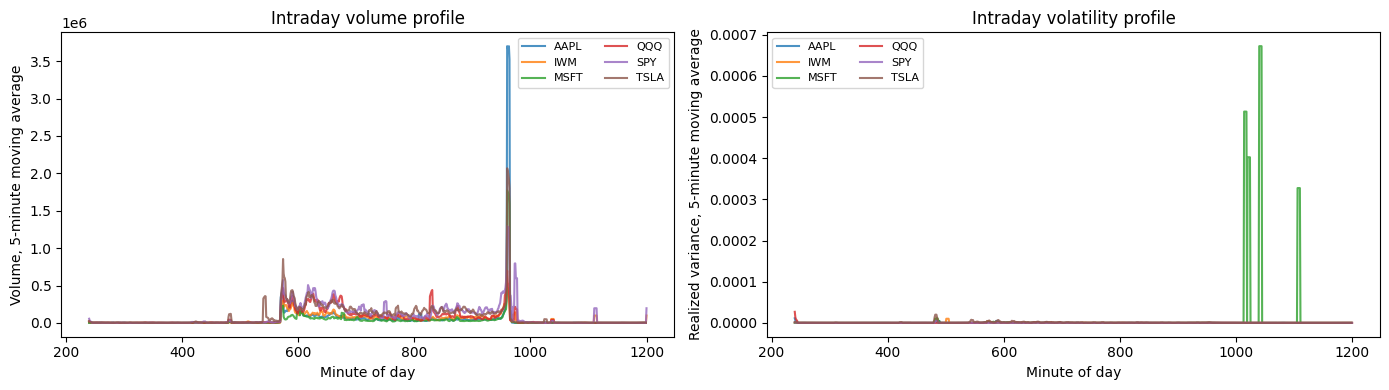

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for symbol, group in trade_bars.groupby('symbol'):
    group = group.sort_values('time_bin')
    axes[0].plot(group['time_bin'], group['total_volume'].rolling(5, min_periods=1).mean(), label=symbol, alpha=0.8)
    axes[1].plot(group['time_bin'], group['realized_var'].rolling(5, min_periods=1).mean(), label=symbol, alpha=0.8)
axes[0].set_title('Intraday volume profile')
axes[0].set_xlabel('Minute of day')
axes[0].set_ylabel('Volume, 5-minute moving average')
axes[1].set_title('Intraday volatility profile')
axes[1].set_xlabel('Minute of day')
axes[1].set_ylabel('Realized variance, 5-minute moving average')
axes[0].legend(ncol=2, fontsize=8)
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()

## 8. Visualizing the processed BBO quote features

The BBO feature file gives top-of-book liquidity features such as spread and quote update intensity.

In [13]:
bbo_features_path = RESEARCH_DIR / 'taq_bbo_features.csv'
bbo = pd.read_csv(bbo_features_path)
bbo.head()

,symbol,minute,nbbo_updates,mean_spread_bps,median_spread_bps,max_spread_bps,mean_depth_imbalance,mean_quoted_depth,first_mid,last_mid,high_mid,low_mid,mid_return,mid_range,quote_intensity
0,AAPL,07:48:32,1,126.442782,126.442782,126.442782,0.0,200.0,172.410,172.410,172.410,172.410,0.0,0.0,1
1,AAPL,07:50:46,1,123.524806,123.524806,123.524806,0.0,200.0,172.435,172.435,172.435,172.435,0.0,0.0,1
2,AAPL,07:50:48,1,123.524806,123.524806,123.524806,0.0,200.0,172.435,172.435,172.435,172.435,0.0,0.0,1
3,AAPL,07:56:39,1,117.691393,117.691393,117.691393,0.0,200.0,172.485,172.485,172.485,172.485,0.0,0.0,1
4,AAPL,08:00:00,1,114.192969,114.192969,114.192969,0.0,200.0,172.515,172.515,172.515,172.515,0.0,0.0,1


In [14]:
bbo_summary = bbo.groupby('symbol').agg(
    bars=('minute', 'count'),
    avg_spread_bps=('mean_spread_bps', 'mean'),
    avg_quote_updates=('nbbo_updates', 'mean'),
    avg_depth_imbalance=('mean_depth_imbalance', 'mean'),
    avg_mid_range=('mid_range', 'mean'),
).reset_index().sort_values('avg_quote_updates', ascending=False)
bbo_summary

,symbol,bars,avg_spread_bps,avg_quote_updates,avg_depth_imbalance,avg_mid_range
1,AMZN,1161,137.417263,25.217054,0.014662,139.567186
0,AAPL,1748,112.148182,22.093822,-0.007888,107.641401
3,GOOGL,943,113.600489,21.608696,-0.099824,78.495846
4,IVV,3291,16.577946,12.011851,0.026248,5.976659
5,IWM,3331,9.572490,10.596217,-0.015830,1.961338
2,DIA,3562,16.243251,10.302639,-0.021981,10.258852


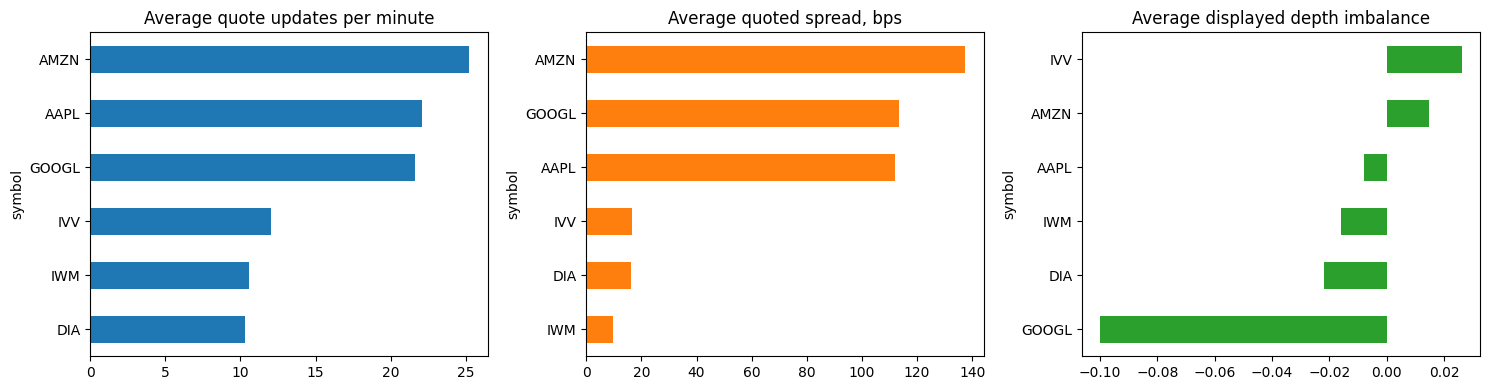

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bbo_summary.sort_values('avg_quote_updates').plot.barh(x='symbol', y='avg_quote_updates', ax=axes[0], legend=False)
axes[0].set_title('Average quote updates per minute')

bbo_summary.sort_values('avg_spread_bps').plot.barh(x='symbol', y='avg_spread_bps', ax=axes[1], legend=False, color='tab:orange')
axes[1].set_title('Average quoted spread, bps')

bbo_summary.sort_values('avg_depth_imbalance').plot.barh(x='symbol', y='avg_depth_imbalance', ax=axes[2], legend=False, color='tab:green')
axes[2].set_title('Average displayed depth imbalance')

plt.tight_layout()

## 9. What else could be downloaded next

If we want more data, I would not immediately download all 200+ GB. I would prioritize by research value:

1. **Full-day consolidated NBBO** from DAILY TAQ: best next step for full-day spread/liquidity features.
2. **NYSE ORDER IMBALANCES**: useful for auction imbalance features.
3. **NYSE OPENBOOK**: useful for full limit-order-book nonlinear dimension reduction.
4. **Additional dates** for trades/NBBO: necessary for reliable predictive tests.

Downloading everything is possible, but it is around 200+ GB more than what is already local.

## Final summary

What we have done:

- Downloaded representative TAQ files.
- Built parsers and one-minute feature pipelines.
- Built visual summaries of quote and trade features.
- Created a concrete nonlinear dimension reduction idea based on intraday curves.

What remains:

- Decide whether to download more files.
- If yes, prioritize full-day NBBO, order imbalance, OpenBook, or more dates.
- Use more days/symbols for a stronger PCA vs nonlinear dimension reduction experiment.